In [186]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import time
import sys
from pathlib import Path

for project_root in (Path.cwd(), Path.cwd().parent):
    if (project_root / 'binary_sync').is_dir():
        sys.path.insert(0, str(project_root))
        break

from matplotlib.lines import Line2D
from binary_sync.model import sample_instance, Graph
from binary_sync.bp import bp_corr2
from binary_sync.spectral import spectral_corr2
from binary_sync.low_degree import low_degree_corr2 as low_degree_corr
from binary_sync.percolation import estimate_percolation_bound

## Graph Visualization

In [187]:
def draw_graph(
    graph,
    source,
    target,
    ax=None,
    seed=0,
    title=None,
    positions=None,
):
    if source not in graph.nodes:
        raise ValueError("The source is not in the graph.")

    if target not in graph.nodes:
        raise ValueError("The target is not in the graph.")

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    nx_graph = nx.MultiGraph()
    nx_graph.add_nodes_from(graph.nodes)

    for edge_id, edge in enumerate(graph.edges):
        nx_graph.add_edge(edge.u, edge.v, key=edge_id)

    if positions is None:
        positions = nx.spring_layout(nx_graph, seed=seed)

    ordinary_nodes = [
        node
        for node in graph.nodes
        if node not in {source, target}
    ]

    nx.draw_networkx_edges(
        nx_graph,
        positions,
        ax=ax,
        width=1.8,
        edge_color="gray",
    )

    nx.draw_networkx_nodes(
        nx_graph,
        positions,
        nodelist=ordinary_nodes,
        ax=ax,
        node_size=700,
        node_color="lightblue",
        edgecolors="black",
    )

    nx.draw_networkx_nodes(
        nx_graph,
        positions,
        nodelist=[source],
        ax=ax,
        node_size=850,
        node_color="mediumseagreen",
        edgecolors="black",
        linewidths=2,
    )

    nx.draw_networkx_nodes(
        nx_graph,
        positions,
        nodelist=[target],
        ax=ax,
        node_size=850,
        node_color="darkorange",
        edgecolors="black",
        linewidths=2,
    )



    nx.draw_networkx_labels(
        nx_graph,
        positions,
        labels={source: "s", target: "t"},
        ax=ax,
        font_size=10,
    )

    # legend_handles = [
    #     Line2D(
    #         [0],
    #         [0],
    #         marker="o",
    #         color="none",
    #         markerfacecolor="mediumseagreen",
    #         markeredgecolor="black",
    #         markersize=11,
    #         label=f"Source: {source}",
    #     ),
    #     Line2D(
    #         [0],
    #         [0],
    #         marker="o",
    #         color="none",
    #         markerfacecolor="darkorange",
    #         markeredgecolor="black",
    #         markersize=11,
    #         label=f"Sink: {target}",
    #     ),
    # ]

    # ax.legend(
    #     handles=legend_handles,
    #     loc="best",
    #     frameon=False,
    # )

    if title is not None:
        ax.set_title(title)

    ax.set_axis_off()
    return ax

## Trees and Paths

In [188]:
def make_path(p_values):
    graph = Graph()

    for i, p in enumerate(p_values):
        graph.add_edge(i, i + 1, p)

    return graph, 0, len(p_values)

In [189]:
p_values = [0.2, 0.2, 0.2, 0.2]

path, s, t = make_path(p_values)

<Axes: >

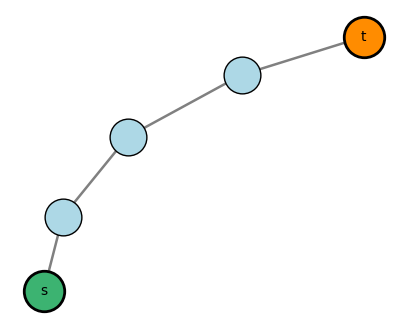

In [190]:
draw_graph(path, s, t)

In [191]:
start = time.perf_counter()
# result_bp = bp_corr2(path, s, t, n_samples=5000, seed=0)['corr2']
result_bp_random = bp_corr2(path, s, t, n_samples=5000, seed=0, init="random")['corr2']
runtime_bp = time.perf_counter() - start

start = time.perf_counter()
result_spectral = spectral_corr2(path, s, t, alg="naive", n_samples=5000, seed=0)['corr2']
runtime_spectral = time.perf_counter() - start

start = time.perf_counter()
result_low_degree = low_degree_corr(path, 4, s, t)
runtime_low_degree = time.perf_counter() - start

percolation_bound = estimate_percolation_bound(path, s, t)["bound"]

In [192]:
print(f"BP estimate: {result_bp_random:.4f} (runtime: {runtime_bp:.4f} s)")
print(f"Naive Spectral: {result_spectral:.4f} (runtime: {runtime_spectral:.4f} s)")
print(f"Low-degree: {result_low_degree:.4f} (runtime: {runtime_low_degree:.4f} s)")
print(f"Percolation Upper bound: {percolation_bound:.4f}")

BP estimate: 0.0184 (runtime: 0.9761 s)
Naive Spectral: 0.0184 (runtime: 0.1340 s)
Low-degree: 0.0168 (runtime: 0.0001 s)
Percolation Upper bound: 0.0168


## S-P graphs

In [193]:
def make_parallel_branch_graph(m=3, n=3, p=0.1):
    graph = Graph()
    observations = []
    positions = {
        "s": (0, 0),
        "t": (8, 0),
        "a": (4, -3.5),
    }

    # The displayed observation on (s, a) is -1.
    graph.add_edge("s", "a", p)
    observations.append(-1)

    # Paths s -- c_i -- d_i -- t.
    top_heights = np.linspace(2.5, 0.5, m)

    for i, height in enumerate(top_heights, start=1):
        c = f"c_{i}"
        d = f"d_{i}"

        positions[c] = (3, height)
        positions[d] = (5, height)

        graph.add_edge("s", c, p)
        observations.append(1)

        graph.add_edge(c, d, p)
        observations.append(1)

        graph.add_edge(d, "t", p)
        observations.append(1)

    # Paths a -- b_j -- t.
    a_position = np.array(positions["a"], dtype=float)
    t_position = np.array(positions["t"], dtype=float)

    offsets = np.linspace(0.8, -0.8, n)

    for j, offset in enumerate(offsets, start=1):
        b = f"b_{j}"
        fraction = j / (n + 1)

        base_position = (
            (1 - fraction) * a_position
            + fraction * t_position
        )

        positions[b] = tuple(
            base_position + np.array([0, offset])
        )

        graph.add_edge("a", b, p)
        observations.append(1)

        graph.add_edge(b, "t", p)
        observations.append(1)

    return (
        graph,
        "s",
        "t",
        np.array(observations, dtype=int),
        positions,
    )

In [194]:
sp_graph, s, t, observations, positions = make_parallel_branch_graph(m=3, n=5, p=0.2)

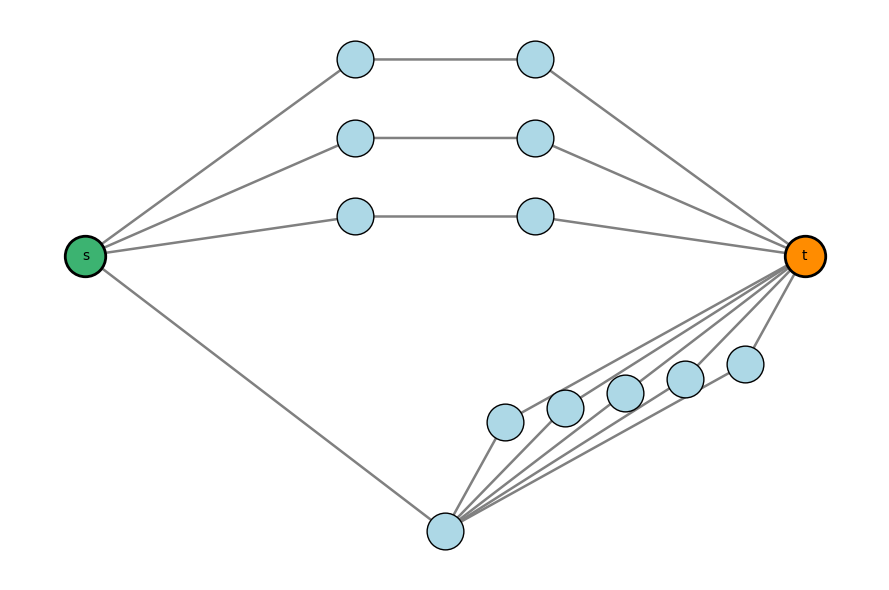

In [195]:

fig, ax = plt.subplots(figsize=(9, 6))

draw_graph(
    sp_graph,
    source=s,
    target=t,
    positions=positions,
    ax=ax,
    # title=r"Parallel-branch graph: $m=n=3$",
)

plt.tight_layout()
plt.show()

In [267]:
start = time.perf_counter()
result_bp = bp_corr2(sp_graph, s, t, n_samples=200, seed=3, init="zero")['corr2']
bp_var = bp_corr2(sp_graph, s, t, n_samples=200, seed=3, init="zero")['standard_error']
runtime_bp = time.perf_counter() - start

start = time.perf_counter()
result_spectral = spectral_corr2(sp_graph, s, t, alg="naive", n_samples=200, seed=3)['corr2']
runtime_spectral = time.perf_counter() - start

start = time.perf_counter()
result_low_degree = low_degree_corr(sp_graph, 4, s, t)
runtime_low_degree = time.perf_counter() - start

# To exactg computation of correlation

percolation_bound = estimate_percolation_bound(sp_graph, s, t)["bound"]

In [268]:
print(f"BP estimate: {result_bp:.4f}",  f"(runtime: {runtime_bp:.4f} s)")
print(f"BP standard error: {bp_var:.4f}")
print(f"Spectral estimate: {result_spectral:.4f}", f"(runtime: {runtime_spectral:.4f} s)")
print(f"Low-degree estimate: {result_low_degree:.4f}", f"(runtime: {runtime_low_degree:.4f} s)")
print(f"Percolation Upper bound: {percolation_bound:.4f}")

BP estimate: 0.2052 (runtime: 13.1555 s)
BP standard error: 0.0504
Spectral estimate: 0.0961 (runtime: 0.0133 s)
Low-degree estimate: 0.2472 (runtime: 0.0078 s)
Percolation Upper bound: 0.2883


## Grids

In [207]:
def make_grid(side=5, p=0.1, rng=None):
    """
    Construct a side x side grid with homogeneous flip probability p.

    Returns
    -------
    graph
    source
    target
    observations : one +/-1 observation per edge
    positions     : plotting positions
    """
    if side < 2:
        raise ValueError("side must be at least 2")

    if rng is None:
        rng = np.random.default_rng()

    graph = Graph()
    observations = []
    positions = {}

    middle_row = side // 2

    def node(row, col):
        if row == middle_row and col == 0:
            return "s"
        if row == middle_row and col == side - 1:
            return "t"
        return f"v_{row}_{col}"

    for row in range(side):
        for col in range(side):
            u = node(row, col)
            positions[u] = (col, -row)

            if row > 0:
                v = node(row - 1, col)
                graph.add_edge(v, u, p)
                observations.append(
                    -1 if rng.random() < p else 1
                )

            if col > 0:
                v = node(row, col - 1)
                graph.add_edge(v, u, p)
                observations.append(
                    -1 if rng.random() < p else 1
                )

    return (
        graph,
        "s",
        "t",
        np.asarray(observations, dtype=int),
        positions,
    )

In [244]:
grid, s, t, observations, positions = make_grid(side=6, p=0.10, rng=np.random.default_rng(seed=0))

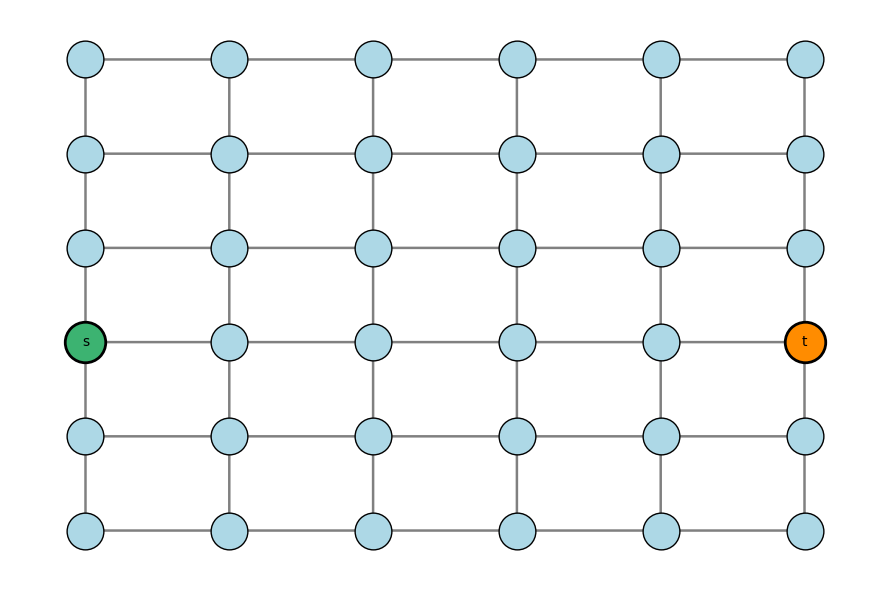

In [245]:
fig, ax = plt.subplots(figsize=(9, 6))

draw_graph(
    grid,
    source=s,
    target=t,
    positions=positions,
    ax=ax,
)

plt.tight_layout()
plt.show()

In [280]:
start = time.perf_counter()
# result_bp_grid = bp_corr2(grid, s, t, n_samples=100, seed=0, init="random")['corr2']
result_bp_grid_random = bp_corr2(grid, s, t, n_samples=100, seed=5, init="random")['corr2']
runtime_bp_grid = time.perf_counter() - start


In [281]:

start = time.perf_counter()
result_spectral_grid = spectral_corr2(grid, s, t, alg="naive", n_samples=100, seed=5)['corr2']
runtime_spectral_grid = time.perf_counter() - start

In [ ]:
# result_bp_grid_zero = bp_corr2(grid, s, t, n_samples=100, seed=0, init="zero")['corr2']

In [256]:
start = time.perf_counter()
result_low_degree_grid = low_degree_corr(grid, 7, s, t)
runtime_low_degree_grid = time.perf_counter() - start

In [282]:
percolation_bound_grid = estimate_percolation_bound(grid, s, t)["bound"]

In [284]:
print(f"BP estimate: {result_bp_grid_random:.4f} (runtime: {runtime_bp_grid:.4f} s)")
# print(f"BP_estimate (zero init): {result_bp_grid:.4f}")
print(f"Spectral estimate: {result_spectral_grid:.4f} (runtime: {runtime_spectral_grid:.4f} s)")
print(f"Low-degree estimate: {result_low_degree_grid:.4f} (runtime: {runtime_low_degree_grid:.4f} s)")
print(f"Percolation Upper bound: {percolation_bound_grid:.4f}")

BP estimate: 0.4083 (runtime: 15.1789 s)
Spectral estimate: 0.3844 (runtime: 0.0272 s)
Low-degree estimate: 0.2624 (runtime: 776.5501 s)
Percolation Upper bound: 0.7049


## Misc

<Axes: title={'center': 'Heterogeneous Graph'}>

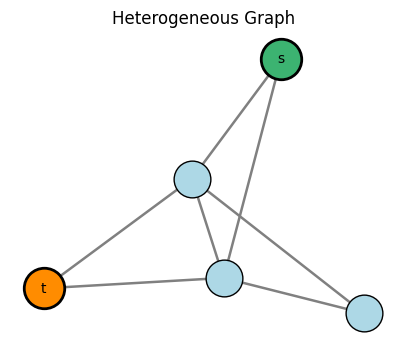

In [285]:
heterogeneous = Graph()

heterogeneous.add_edge("s", "a", 0.2)
heterogeneous.add_edge("a", "t", 0.2)

heterogeneous.add_edge("s", "b", 0.20)
heterogeneous.add_edge("b", "c", 0.2)

heterogeneous.add_edge("a", "b", 0.2)
heterogeneous.add_edge("a", "c", 0.2)
heterogeneous.add_edge("b", "t", 0.2)

draw_graph(heterogeneous, "s", "t", title="Heterogeneous Graph")

In [299]:
random_seed = np.random.choice([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

start = time.perf_counter()
result_bp_misc = bp_corr2(heterogeneous, "s", "t", n_samples=100, seed=random_seed)['corr2']
runtime_bp_misc = time.perf_counter() - start

start = time.perf_counter()
result_spectral_misc = spectral_corr2(heterogeneous, "s", "t", alg="naive", n_samples=100, seed=random_seed)['corr2']
runtime_spectral_misc = time.perf_counter() - start

start = time.perf_counter()
result_low_degree_misc = low_degree_corr(heterogeneous, 5, "s", "t")
runtime_low_degree_misc = time.perf_counter() - start

In [302]:
percolation_bound_misc = estimate_percolation_bound(heterogeneous, "s", "t")["bound"]

In [303]:
print(f"BP estimate: {result_bp_misc:.4f} (runtime: {runtime_bp_misc:.4f} s)" )
print(f"Spectral estimate: {result_spectral_misc:.4f} (runtime: {runtime_spectral_misc:.4f} s)" )
print(f"Low-degree estimate: {result_low_degree_misc:.4f} (runtime: {runtime_low_degree_misc:.4f} s)" )
print(f"Percolation Upper bound: {percolation_bound_misc:.4f}")

BP estimate: 0.1823 (runtime: 0.6449 s)
Spectral estimate: 0.1024 (runtime: 0.0039 s)
Low-degree estimate: 0.2459 (runtime: 0.0009 s)
Percolation Upper bound: 0.2906
